### 1. Importação de Bibliotecas e Configurações
Importamos as dependências necessárias e fazemos o reload dos nossos módulos locais (configurações, dataloaders e modelo) para garantir que as alterações mais recentes sejam refletidas.

In [17]:
import torch.utils.data as data
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import torchvision.transforms as transforms
import torch.optim as optim
import torch
import importlib

import config as cfg
importlib.reload(cfg)

import dataset.dataloader as dl
importlib.reload(dl)

import classifier.cnn as classifier
importlib.reload(classifier)

import utils.metrics as mtcs
importlib.reload(mtcs)

# Dispositivo de hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Gerar pastas de resultados
cfg.CNN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
cfg.CNN_MODELS_DIR.mkdir(parents=True, exist_ok=True)
cfg.CNN_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

Using device: cpu


### 2. Preparação dos Dados e Divisão (Train, Val, Test)
Carregamos os rótulos e aplicamos uma divisão estratificada para garantir que as 75 classes de borboletas estejam devidamente representadas nos conjuntos de treinamento, validação e teste. Em seguida, criamos os `DataLoaders` respectivos.

In [18]:
# Load the data
df = pd.read_csv(cfg.LABELS_PATH)

# Preprocessing: Inicialmente mantemos transforms básicos
data_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

# Stratified Split
train_df, val_df, test_df = dl.get_stratified_splits(
    df, 
    test_size=cfg.TEST_SIZE, 
    val_size=cfg.VAL_SIZE, 
    random_state=cfg.RANDOM_SEED
)

# Instantiate Datasets
train_dataset = dl.ButterflyDataset(df=train_df, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
val_dataset = dl.ButterflyDataset(df=val_df, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
test_dataset = dl.ButterflyDataset(df=test_df, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)

# Instantiate DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)

### 3. Análise do Dataset e Balanceamento de Classes
Verificamos a quantidade de dados por partição e analisamos a distribuição das 75 classes de borboletas no conjunto de treino. Como modelos de *Deep Learning* são sensíveis a desbalanceamentos, compreender esta distribuição guiará a nossa estratégia de Data Augmentation com modelos generativos.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Total de classes: {len(train_dataset.classes)}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Análise de Balanceamento (Usando o DataFrame de treino criado no split)
class_counts = train_df['label'].value_counts()

print(f"\nMáximo de imagens em uma classe: {class_counts.max()}")
print(f"Mínimo de imagens em uma classe: {class_counts.min()}")
print(f"Média de imagens por classe: {class_counts.mean():.2f}")

# Plot da distribuição
plt.figure(figsize=(18, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribuição das Classes no Conjunto de Treinamento", fontsize=14)
plt.xlabel("Classes (Borboletas)", fontsize=12)
plt.ylabel("Número de Amostras", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()

dist_plot_path = cfg.PLOTS_DIR / 'class_distribution.png'
plt.savefig(dist_plot_path, dpi=300)
plt.show()

print(f"Gráfico de distribuição salvo em: {dist_plot_path}")

Total de classes: 75
Train samples: 3639
Validation samples: 780
Test samples: 780


### 4. Visualização dos Dados
Vamos extrair um batch do DataLoader de treino para visualizar a diversidade e a variação intra-classe presente no dataset.

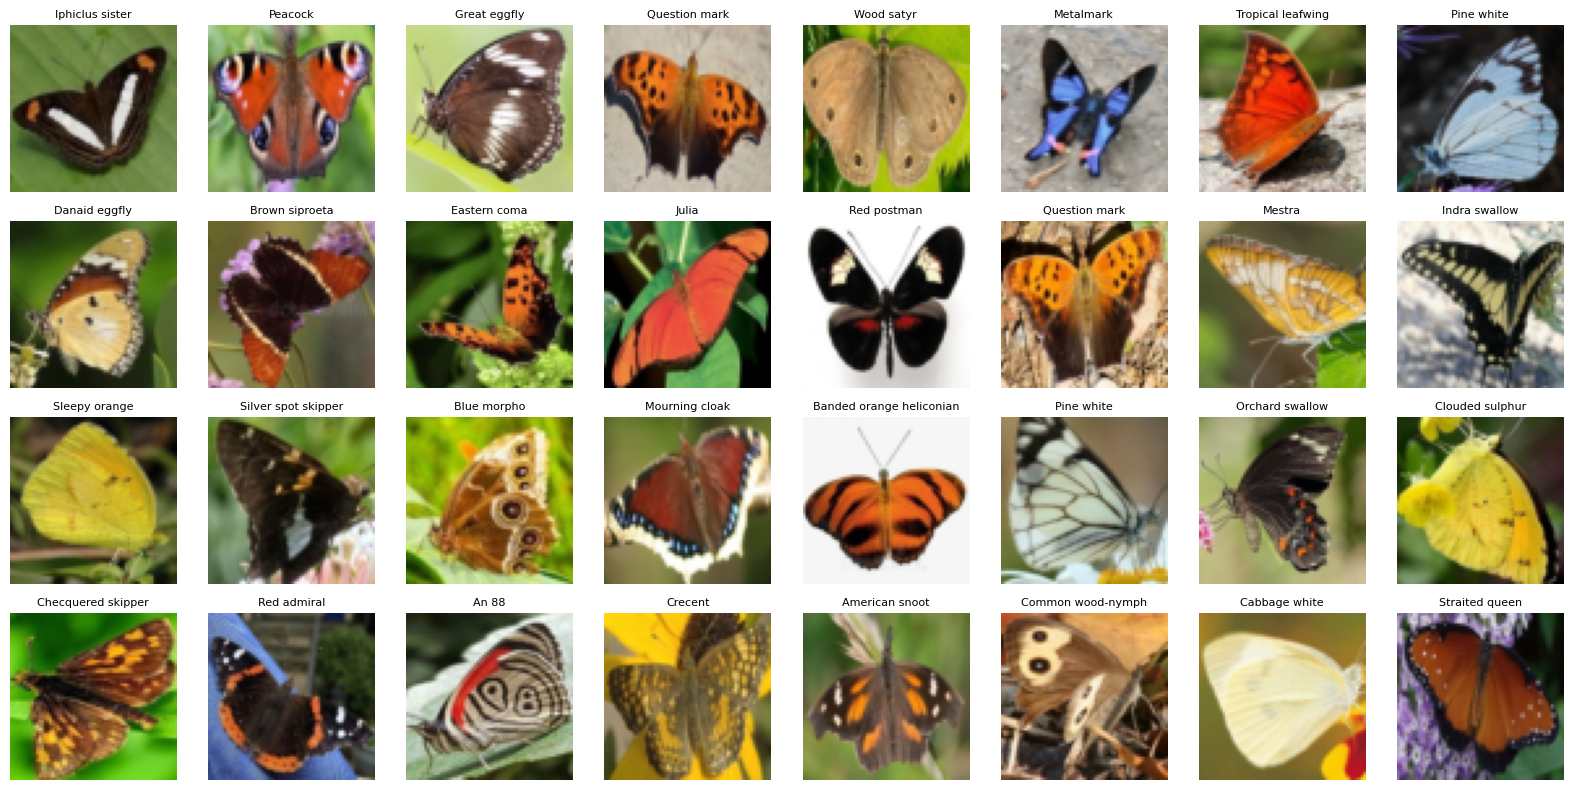

In [20]:
# Get a batch of images from the train dataloader
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = train_dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5. Instanciação e Treinamento do Modelo Baseline
Inicializamos a arquitetura CNN, o otimizador e a função de custo (Loss). Em seguida, iniciamos o treinamento por um número fixo de épocas. O script salvará automaticamente os pesos da última época e da época com a melhor *Validation Loss* dentro da pasta `results/models/`.

In [ ]:
n_classes = len(train_dataset.classes)

model = classifier.BaselineCNN(num_classes=n_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Executando o treino diretamente após a instanciação
best_model, history = classifier.train_cnn(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=cfg.N_EPOCHS,
    save_dir=cfg.CNN_MODELS_DIR
)

mtcs.save_cnn_train(history, cfg.CNN_PLOTS_DIR)


Epoch 1/50
----------


Train Loss: 4.2263 Acc: 0.0261


Val Loss: 4.6763 Acc: 0.0154

Epoch 2/50
----------


Train Loss: 3.9502 Acc: 0.0412


Val Loss: 3.7559 Acc: 0.0564

Epoch 3/50
----------


...

Train Loss: 1.5410 Acc: 0.5238


Val Loss: 1.5157 Acc: 0.5487

Epoch 44/50
----------


Train Loss: 1.5177 Acc: 0.5221


Val Loss: 1.6516 Acc: 0.5205

Epoch 45/50
----------


Train:  68%|██████▊   | 78/114 [01:07<00:35,  1.03it/s]

### 6. Avaliação no Conjunto de Teste
Com o modelo treinado, avaliamos sua performance no conjunto de teste (dados nunca vistos pelo modelo). Extraímos métricas detalhadas como Precision, Recall e F1-Score, além da Matriz de Confusão, para entender onde o modelo baseline acerta e quais espécies de borboletas ele mais confunde.

In [ ]:
mtcs.save_cnn_train(history, cfg.CNN_PLOTS_DIR)
# Avaliando o modelo e salvando a matriz de confusão
cm_path = cfg.CNN_PLOTS_DIR / 'baseline_confusion_matrix.png'
mtcs.evaluate_cnn(best_model, test_dataset, test_loader, device=device, save_path=cm_path, results_dir=cfg.CNN_RESULTS_DIR)